
### Objectiu del departament d'Anàlisi de Perfil Client:

> Quines combinacions de característiques demogràfiques (com edat, nivell educatiu i ocupació) són més comunes entre els clients que utilitzen múltiples productes financers del banc: loan, hipoteca, dipòsit?

### Llibreries i càrrega de dades

In [45]:
%pip install plottable
%pip install kmodes
%pip install yellowbrick


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [90]:
"""Libreries que poden ser necessàries"""

# Manejo de datos
import pandas as pd                 # Análisis y manipulación de datos en tablas
import numpy as np                  # Cálculos numéricos y matrices
import os                           # Gestión de rutas de archivos

# Visualización de datos
import matplotlib.pyplot as plt     # Gráficos básicos en 2D
import seaborn as sns               # Gráficos estadísticos mejorados
import plotly.express as px         # Gráficos interactivos simplificados
import plotly.graph_objects as go   # Control avanzado de gráficos en Plotly
import plotly.io as pio             # Interfaz de entrada/salida de Plotly
import squarify                     # Visualización de diagramas de "treemap"
from plottable import Table         # Visualización de tablas
import matplotlib.colors as mcolors # Colores y mapas de colores

# Clustering y agrupamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer


In [47]:
df = pd.read_csv("../Data/df_250526.csv")

Paleta de colors

In [48]:
custom_palette = ["#AABBC8", "#2CCED1", "#5F6F81", "#DCE3EA", "#2E2F36"]  
sns.set_palette(sns.color_palette(custom_palette))

### Extracte KPIs

In [49]:

# Variables 
contactados   = df.nunique().id                                     # Número total de clientes contactados
suscribieron  = df[df['deposit'] == True].nunique().id             # Número de clientes que suscribieron 
duracion_llam = df[df['deposit'] == True].duration.sum()           # Duración de llamadas a suscriptores
llam_telf = df[df['contact'] == 'telephone']['campaign'].sum()      # Número de llamadas realizadas por teléfono
llam_cell = df[df['contact'] == 'cellular']['campaign'].sum()       # Número de llamadas realizadas por movil
llam = df['campaign'].sum()                                         # Número total de llamadas
contatos_previos_sus = df[df['deposit'] == True]['previous'].sum() # Número de contactos previos a suscriptores
suscribieron_por_mes = df[df['deposit'] == True].groupby('month').count()['deposit']  # Suscriptores en el mes
contactos_por_mes = df.groupby('month').count()['deposit']          # clientes contactados en el mes      
conversion_por_mes = suscribieron_por_mes / contactos_por_mes       # conversión por mes


# Prints
print("El número total de clientes contactados es:",contactados)
print("El número de suscriptores es:",suscribieron)
print("La duración total de las llamadas a suscriptores es:",duracion_llam)
print("El número de llamadas realizadas a teléfono fijo es: ", llam_telf)
print("El número de llamadas realizadas a móvil es: ", llam_cell)
print("El número total de llamadas realizadas es: ", llam)
print("El número total de contactos previos de los suscriptores es:", contatos_previos_sus)
print("La conversión por mes es: ", conversion_por_mes)

El número total de clientes contactados es: 26180
El número de suscriptores es: 12499
La duración total de las llamadas a suscriptores es: 6763175
El número de llamadas realizadas a teléfono fijo es:  5399
El número de llamadas realizadas a móvil es:  45476
El número total de llamadas realizadas es:  65801
El número total de contactos previos de los suscriptores es: 14668
La conversión por mes es:  month
Apr    0.630156
Aug    0.456259
Dec    0.902344
Feb    0.576944
Jan    0.409548
Jul    0.413754
Jun    0.446554
Mar    0.903374
May    0.334334
Nov    0.426036
Oct    0.838816
Sep    0.844941
Name: deposit, dtype: float64


In [50]:
#KPIs
kpi1 = suscribieron/contactados          # porcentaje de conversión a depósito
kpi2 = duracion_llam/suscribieron        # promedio de duración de llamadas a suscriptores
kpi3_tel = llam_telf/llam                # porcentaje de llamadas a teléfono
kpi3_cell = llam_cell/llam               # porcentaje de llamadas a móvil
kpi3 = (llam_telf+llam_cell)/llam        # porcentaje de llamadas a teléfono o móvil
kpi4 = contatos_previos_sus/suscribieron # promedio de contactos previos a suscriptores
kpi5 = conversion_por_mes.idxmax()       # mes con mayor tasa de conversión
kpi5_tasa = conversion_por_mes.max()     # tasa de conversión del mes con mayor tasa de conversión




# Prints
print("KPI 1: El porcentaje de conversión a depósito es ",kpi1*100,"%")
print("KPI 2: La duración media de las llamadas a suscriptoreses",kpi2)
# print("KPI 3: El porcentaje de llamadas realizadas por teléfono o móvil es ",kpi3*100,"%")
print("KPI 3.1: El porcentaje de llamadas realizadas por teléfono fijo es ",kpi3_tel*100,"%")
print("KPI 3.2: El porcentaje de llamadas realizadas por teléfono móvil es ",kpi3_cell*100,"%")
print("KPI 4: El porcentaje de contactos previos a suscriptores es ",kpi4)
print("KPI 5: El mes amb millor conversió ha sigut", kpi5, "amb una taxa de conversió de", kpi5_tasa)

KPI 1: El porcentaje de conversión a depósito es  47.74255156608098 %
KPI 2: La duración media de las llamadas a suscriptoreses 541.0972877830227
KPI 3.1: El porcentaje de llamadas realizadas por teléfono fijo es  8.205042476558107 %
KPI 3.2: El porcentaje de llamadas realizadas por teléfono móvil es  69.11141168067356 %
KPI 4: El porcentaje de contactos previos a suscriptores es  1.1735338827106168
KPI 5: El mes amb millor conversió ha sigut Mar amb una taxa de conversió de 0.9033742331288344


# Anàlisi 

### Càlcul per a clients que no han contractat res

In [51]:
# Número de clients que van suscriure, tenen prèstec i una hipoteca 
df_0contractats = df[(df['deposit'] == False) & (df['loan'] == False) & (df['housing'] == False)] 

df_0contractats_numero = df_0contractats.nunique().id 
print("El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es:", df_0contractats_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_0contractats = df_0contractats.groupby(['age', 'education','job'])


# Creem una taula per al càlcul de conversions
taula_pefils_0contractats = []

# Recorrem la taula calculant la conversió de cada grup
for (edat, educacio, feina), grup in df_0contractats:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_pefils_0contractats.append({
        'age': edat,
        'education': educacio,
        'job': feina,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_pefils_0contractats = pd.DataFrame(taula_pefils_0contractats)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_pefils_0contractats = taula_pefils_0contractats.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_pefils_0contractats.head(15)  # Mostrem les primeres 15 files de la taula

El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es: 4928


,age,education,job,número
152,33,tertiary,management,82
98,30,tertiary,management,74
117,31,tertiary,management,70
135,32,tertiary,management,60
170,34,tertiary,management,55
112,31,secondary,technician,48
209,36,tertiary,management,46
166,34,secondary,technician,45
288,40,tertiary,management,45
95,30,secondary,technician,41


### Càlcul per a clients que han contractat només un producte


In [52]:
# Crear una nova columna temporal que compta quants productes ha contractat el client
df['productes_contractats'] = df[['deposit', 'loan', 'housing']].sum(axis=1)

# Filtrar els clients que n'han contractat exactament un
df_1contractats = df[df['productes_contractats'] == 1].copy()


df_1contractats_numero = df_1contractats.nunique().id 
print("El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es:", df_1contractats_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_1contractats = df_1contractats.groupby(['age', 'education','job'])


# Creem una taula per al càlcul de conversions
taula_pefils_1contractats = []

# Recorrem la taula calculant la conversió de cada grup
for (edat, educacio, feina), grup in df_1contractats:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_pefils_1contractats.append({
        'age': edat,
        'education': educacio,
        'job': feina,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_pefils_1contractats = pd.DataFrame(taula_pefils_1contractats)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_pefils_1contractats = taula_pefils_1contractats.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_pefils_1contractats.head(15)  # Mostrem les primeres 15 files de la taula


El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es: 14777


,age,education,job,número
214,31,tertiary,management,176
348,36,tertiary,management,170
267,33,tertiary,management,161
295,34,tertiary,management,150
187,30,tertiary,management,147
240,32,tertiary,management,146
320,35,tertiary,management,144
374,37,tertiary,management,134
161,29,tertiary,management,106
135,28,tertiary,management,95


### Càlcul per a clients que han contractat més d'un producte


In [53]:
# Filtrar els clients que n'han contractat més d’un (>=2)
df_mes_dun_contractat = df[df['productes_contractats'] >= 2].copy()

# Eliminar la columna temporal si no cal
df_mes_dun_contractat.drop(columns='productes_contractats', inplace=True)


df_mes_dun_contractat_numero = df_mes_dun_contractat.nunique().id 
print("El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es:", df_mes_dun_contractat_numero)


# Agrupem el dataframe per la combinació de les característiques demogràfiques 
df_mes_dun_contractat = df_mes_dun_contractat.groupby(['age', 'education','job'])


# Creem una taula per al càlcul de conversions
taula_df_mes_dun_contractat = []

# Recorrem la taula calculant la df_mes_dun_contractat de cada grup
for (edat, educacio, feina), grup in df_mes_dun_contractat:
    numero = grup.nunique().id

    # Afegim cada resultat a la taula
    taula_df_mes_dun_contractat.append({
        'age': edat,
        'education': educacio,
        'job': feina,
        'número': numero,
    })

# Convertim la taula de conversió en un dataframe 
taula_df_mes_dun_contractat = pd.DataFrame(taula_df_mes_dun_contractat)

# taula_pefils = taula_pefils.set_index(['feina', 'estat_civil', 'educació'])  # Establim l'índex de la taula

# Ordenem per 
taula_df_mes_dun_contractat = taula_df_mes_dun_contractat.sort_values(by='número', ascending=False)  # Ordenem la taula per número de persones

# Reordenem les columnes de la taula

taula_df_mes_dun_contractat.head(15)  # Mostrem les primeres 15 files de la taula



El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es: 6475


,age,education,job,número
214,35,tertiary,management,99
171,33,tertiary,management,72
136,31,tertiary,management,72
127,31,secondary,blue-collar,71
289,39,tertiary,management,67
194,34,tertiary,management,67
154,32,tertiary,management,63
110,30,secondary,blue-collar,63
202,35,secondary,blue-collar,55
183,34,secondary,blue-collar,55


### Verificació dels tres grups

In [54]:
print("El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es:", df_0contractats_numero)
print("El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es:", df_1contractats_numero)
print("El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es:", df_mes_dun_contractat_numero)

print("La suma de los anteriores es", df_0contractats_numero + df_1contractats_numero + df_mes_dun_contractat_numero)


print("El total de clientes contactados es", df.nunique().id)


El número de clientes que no suscribieron, no tienen préstamo ni hipoteca es: 4928
El número de clientes que o bien suscribieron, o bien tienen préstamo o hipoteca es: 14777
El número de clientes que contrataron dos o más productes entre suscribirse, préstamo o hipoteca es: 6475
La suma de los anteriores es 26180
El total de clientes contactados es 26180


## Elbow method para encontrar k óptimo
Calculo el costo para diferentes valores de l entre 2 - 9 (inclusive)

https://es.wikipedia.org/wiki/M%C3%A9todo_del_codo_(agrupamiento)
El método consiste en graficar la variación explicada en función del número de conglomerados y elegir el codo de la curva como el número de conglomerados a utilizar. Utilizar el "codo" o la "rodilla de una curva" como punto de corte es un método común en la optimización matemática para elegir aquel punto a partir del cual los rendimientos decrecientes ya no justifican el costo adicional.

En este caso, el codo está en el 3.

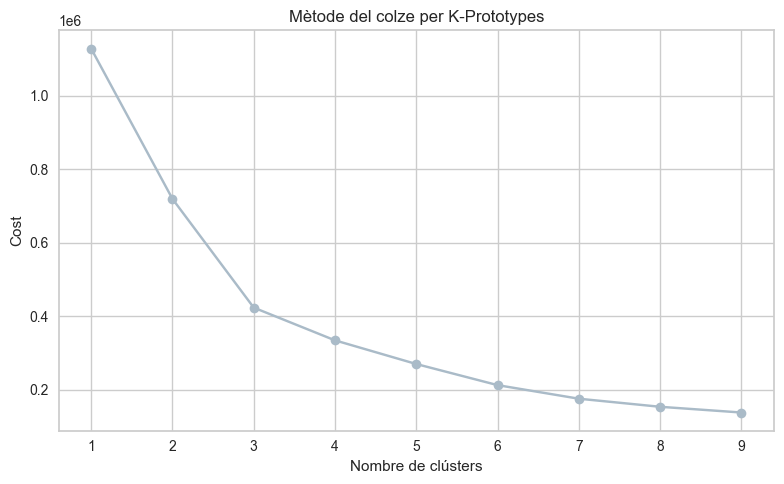

In [55]:
# Unim les tres taules
df_clusters = pd.concat([
    taula_pefils_0contractats.assign(contractats='Cap'),
    taula_pefils_1contractats.assign(contractats='Un'),
    taula_df_mes_dun_contractat.assign(contractats='Més d\'un')
], ignore_index=True)

# Preparem les dades per clusteritzar
X = df_clusters[['número', 'age', 'education', 'job', 'contractats']].copy()
X[['job', 'education', 'contractats']] = X[['job', 'education', 'contractats']].astype(str)

# Fem un encode per a les categories
X_encoded = X.copy()
X_encoded[['job', 'education', 'contractats']] = X_encoded[['job', 'education', 'contractats']].astype(str)

# Elbow method amb KPrototypes
X_matrix = X_encoded[['número', 'age', 'job', 'education', 'contractats']].values

costs = []
K_range = range(1, 10)
for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0)
    kproto.fit_predict(X_matrix, categorical=[2, 3, 4])
    costs.append(kproto.cost_)

# Dibuixar el gràfic del mètode del colze
plt.figure(figsize=(8,5))
plt.plot(K_range, costs, marker='o')
plt.xlabel('Nombre de clústers')
plt.ylabel('Cost')
plt.title('Mètode del colze per K-Prototypes')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()



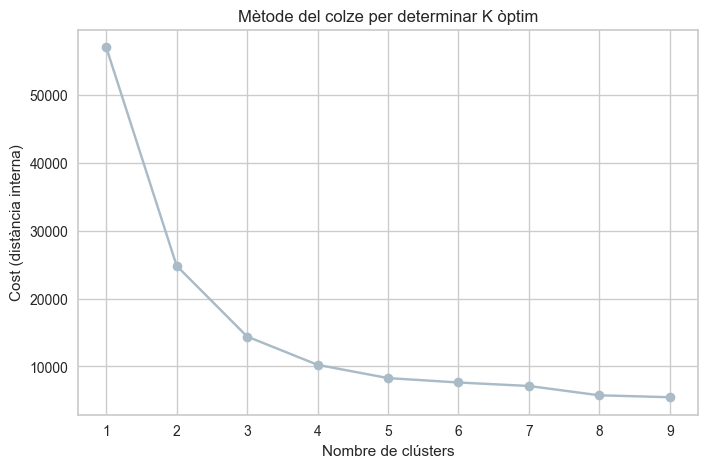

In [56]:

# Seleccionem les columnes rellevants
X = taula_pefils_0contractats[['número', 'job', 'education']].copy()
X[['job', 'education']] = X[['job', 'education']].astype(str)

costs = []
K = range(1, 10)

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    kproto.fit_predict(X, categorical=[1, 2])
    costs.append(kproto.cost_)

# Dibuixar el gràfic del colze
plt.figure(figsize=(8, 5))
plt.plot(K, costs, marker='o')
plt.xlabel('Nombre de clústers')
plt.ylabel('Cost (distància interna)')
plt.title('Mètode del colze per determinar K òptim')
plt.grid(True)
plt.show()

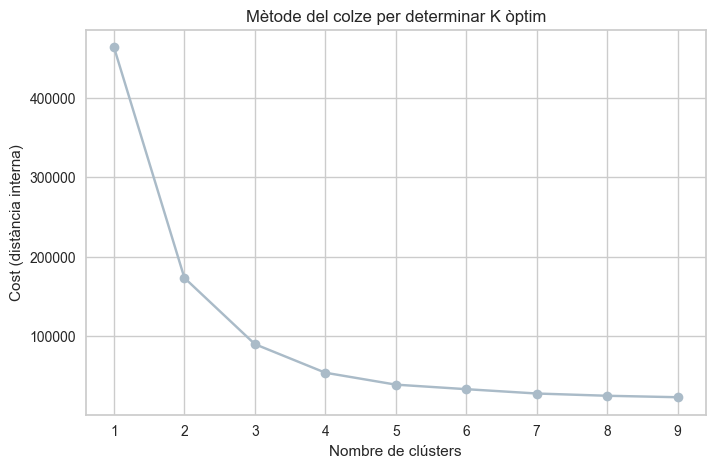

In [57]:
# Seleccionem les columnes rellevants
X = taula_pefils_1contractats[['número', 'job', 'education']].copy()
X[['job', 'education']] = X[['job', 'education']].astype(str)

costs = []
K = range(1, 10)

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    kproto.fit_predict(X, categorical=[1, 2])
    costs.append(kproto.cost_)

# Dibuixar el gràfic del colze
plt.figure(figsize=(8, 5))
plt.plot(K, costs, marker='o')
plt.xlabel('Nombre de clústers')
plt.ylabel('Cost (distància interna)')
plt.title('Mètode del colze per determinar K òptim')
plt.grid(True)
plt.show()

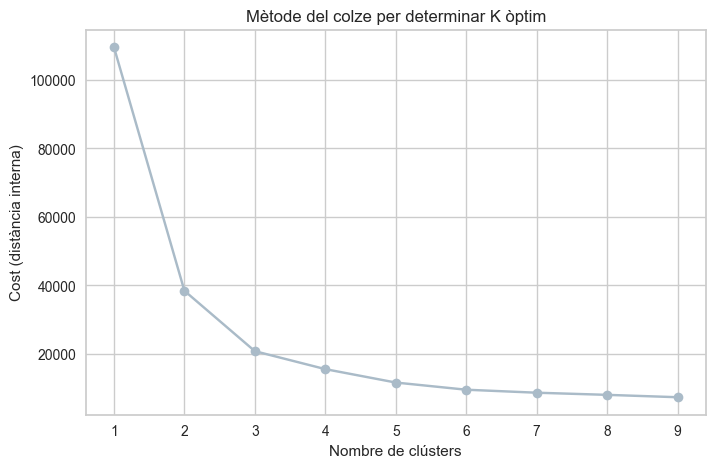

In [58]:
# Seleccionem les columnes rellevants
X = taula_df_mes_dun_contractat[['número', 'job', 'education']].copy()
X[['job', 'education']] = X[['job', 'education']].astype(str)

costs = []
K = range(1, 10)

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    kproto.fit_predict(X, categorical=[1, 2])
    costs.append(kproto.cost_)

# Dibuixar el gràfic del colze
plt.figure(figsize=(8, 5))
plt.plot(K, costs, marker='o')
plt.xlabel('Nombre de clústers')
plt.ylabel('Cost (distància interna)')
plt.title('Mètode del colze per determinar K òptim')
plt.grid(True)
plt.show()

## Clusteritació

Aplquem KMeans amb 3 cluster per a cadascun d'aquests grups

### Càlcul per a clients que no han contractat res

In [65]:

# Select columns to use for clustering (age, education, job)
X = taula_pefils_0contractats[['age', 'education', 'job']]

# One-hot encode categorical columns (education, job)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[['education', 'job']])

# Combine age with encoded categorical features
import numpy as np
X_numeric = np.column_stack([X['age'].values, X_encoded])

# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_numeric)

# Add cluster labels to dataframe
taula_pefils_0contractats['cluster'] = clusters

# Check results
print(taula_pefils_0contractats.head())

     age education         job  número  cluster
152   33  tertiary  management      82        2
98    30  tertiary  management      74        2
117   31  tertiary  management      70        2
135   32  tertiary  management      60        2
170   34  tertiary  management      55        2


### Càlcul per a clients que han contractat només un producte


In [67]:
# For taula_pefils_1contractats
X1 = taula_pefils_1contractats[['age', 'education', 'job']]
X1_encoded = encoder.fit_transform(X1[['education', 'job']])
X1_numeric = np.column_stack([X1['age'].values, X1_encoded])
clusters1 = kmeans.fit_predict(X1_numeric)
taula_pefils_1contractats['cluster'] = clusters1
print(taula_pefils_1contractats.head())




     age education         job  número  cluster
214   31  tertiary  management     176        0
348   36  tertiary  management     170        0
267   33  tertiary  management     161        0
295   34  tertiary  management     150        0
187   30  tertiary  management     147        0


### Càlcul per a clients que han contractat més d'un producte


In [69]:
# For taula_df_mes_dun_contractat
X2 = taula_df_mes_dun_contractat[['age', 'education', 'job']]
X2_encoded = encoder.fit_transform(X2[['education', 'job']])
X2_numeric = np.column_stack([X2['age'].values, X2_encoded])
clusters2 = kmeans.fit_predict(X2_numeric)
taula_df_mes_dun_contractat['cluster'] = clusters2
print(taula_df_mes_dun_contractat.head())


     age  education          job  número  cluster
214   35   tertiary   management      99        2
171   33   tertiary   management      72        1
136   31   tertiary   management      72        1
127   31  secondary  blue-collar      71        1
289   39   tertiary   management      67        2


## Quants grups demogràfics hi ha a cada clúster?


### Càlcul per a clients que no han contractat res

In [74]:
print ("Clusters de taula_pefils_0contractats")
taula_pefils_0contractats['cluster'].value_counts()


Clusters de taula_pefils_0contractats


cluster
0    305
2    256
1    190
Name: count, dtype: int64

Estadístiques per clúster (edat mitjana, mida mitjana del grup, etc.)

In [77]:
taula_pefils_0contractats.groupby('cluster').agg({
    'age': ['mean', 'min', 'max'],
    'número': ['mean', 'sum', 'count']
})

age            número            
              mean min max      mean   sum count
cluster                                         
0        46.685246  39  54  6.459016  1970   305
1        62.642105  55  89  4.500000   855   190
2        31.281250  18  38  8.214844  2103   256

📚 3. Distribució de categories (educació i professió) per clúster


In [82]:
pd.crosstab(taula_pefils_0contractats['cluster'], taula_pefils_0contractats['education'], normalize='index') * 100


education,primary,secondary,tertiary,unknown
cluster,,,,
0,22.950820,40.655738,21.639344,14.754098
1,28.947368,37.368421,21.578947,12.105263
2,13.281250,43.750000,33.593750,9.375000


In [83]:
pd.crosstab(taula_pefils_0contractats['cluster'], taula_pefils_0contractats['job'], normalize='index') * 100


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,8.852459,13.770492,8.196721,9.508197,12.786885,5.245902,8.196721,8.196721,0.655738,12.786885,6.885246,4.918033
1,7.368421,7.894737,4.736842,7.894737,11.052632,36.842105,5.263158,4.210526,0.000000,6.315789,5.263158,3.157895
2,10.546875,11.328125,4.296875,6.640625,11.328125,0.390625,7.031250,10.156250,14.843750,11.328125,9.375000,2.734375


### Càlcul per a clients que han contractat només un producte


In [75]:
print ("Clusters de taula_pefils_1contractats")
taula_pefils_1contractats['cluster'].value_counts()


Clusters de taula_pefils_1contractats


cluster
1    522
0    492
2    143
Name: count, dtype: int64

Estadístiques per clúster (edat mitjana, mida mitjana del grup, etc.)

In [78]:
taula_pefils_1contractats.groupby('cluster').agg({
    'age': ['mean', 'min', 'max'],
    'número': ['mean', 'sum', 'count']
})

age             número            
              mean min max       mean   sum count
cluster                                          
0        32.056911  18  41  17.394309  8558   492
1        51.109195  42  61  10.026820  5234   522
2        71.230769  62  95   6.888112   985   143

📚 3. Distribució de categories (educació i professió) per clúster


In [87]:
pd.crosstab(taula_pefils_1contractats['cluster'], taula_pefils_1contractats['education'], normalize='index') * 100


education,primary,secondary,tertiary,unknown
cluster,,,,
0,16.666667,35.975610,31.504065,15.853659
1,25.670498,34.099617,22.222222,18.007663
2,27.272727,31.468531,24.475524,16.783217


In [88]:
pd.crosstab(taula_pefils_1contractats['cluster'], taula_pefils_1contractats['job'], normalize='index') * 100


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,10.772358,12.601626,7.113821,5.081301,10.569106,0.609756,8.333333,11.991870,11.585366,10.975610,8.333333,2.032520
1,9.961686,11.494253,7.854406,8.620690,13.793103,8.620690,7.279693,9.003831,0.383142,11.877395,8.237548,2.873563
2,2.797203,2.097902,3.496503,9.790210,9.090909,59.440559,4.195804,0.000000,0.000000,4.895105,2.097902,2.097902


### Càlcul per a clients que han contractat més d'un producte


In [76]:
print ("Clusters de taula_df_mes_dun_contractat")
taula_df_mes_dun_contractat['cluster'].value_counts()

Clusters de taula_df_mes_dun_contractat


cluster
2    255
0    211
1    198
Name: count, dtype: int64

In [79]:
taula_df_mes_dun_contractat.groupby('cluster').agg({
    'age': ['mean', 'min', 'max'],
    'número': ['mean', 'sum', 'count']
})

age             número            
              mean min max       mean   sum count
cluster                                          
0        55.995261  49  78   5.696682  1202   211
1        28.848485  20  34  12.646465  2504   198
2        41.066667  35  48  10.858824  2769   255

📚 3. Distribució de categories (educació i professió) per clúster


In [86]:
pd.crosstab(taula_df_mes_dun_contractat['cluster'], taula_df_mes_dun_contractat['education'], normalize='index') * 100


education,primary,secondary,tertiary,unknown
cluster,,,,
0,24.644550,40.758294,22.748815,11.848341
1,15.656566,46.969697,31.313131,6.060606
2,23.921569,43.137255,24.313725,8.627451


In [89]:
pd.crosstab(taula_df_mes_dun_contractat['cluster'], taula_df_mes_dun_contractat['job'], normalize='index') * 100


job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,9.004739,11.374408,9.478673,4.739336,15.639810,18.483412,5.687204,9.478673,0.000000,12.322275,2.843602,0.947867
1,13.636364,16.666667,7.575758,2.525253,12.626263,0.000000,10.101010,11.111111,7.070707,13.131313,5.555556,0.000000
2,11.764706,14.901961,11.764706,6.274510,13.725490,0.784314,7.450980,10.196078,1.176471,13.725490,8.235294,0.000000


## Centroides

Calcular el centroide de cada clúster vol dir trobar el punt mitjà de totes les observacions d’un clúster al seu espai de característiques (les variables utilitzades per fer el clustering).

Aquest cas, el centroide és un vector numèric, resultat de la mitjana de cada característica per a totes les mostres d’aquell clúster.



Centroides exactes dels clústers generats per KMeans
Nota: cada centroid serà un vector amb longitud igual al nombre de columnes en X_numeric.


In [92]:
# Els centroides en l'espai codificat (age + one-hot encoded education i job)
centroides = kmeans.cluster_centers_

# Mostrar centroides
print("Centroides de cada clúster (espai codificat):")
for i, c in enumerate(centroides):
    print(f"Clúster {i}: {c}")

Centroides de cada clúster (espai codificat):
Clúster 0: [ 5.59952607e+01  2.46445498e-01  4.07582938e-01  2.27488152e-01
  1.18483412e-01  9.00473934e-02  1.13744076e-01  9.47867299e-02
  4.73933649e-02  1.56398104e-01  1.84834123e-01  5.68720379e-02
  9.47867299e-02 -3.46944695e-17  1.23222749e-01  2.84360190e-02
  9.47867299e-03]
Clúster 1: [ 2.88484848e+01  1.56565657e-01  4.69696970e-01  3.13131313e-01
  6.06060606e-02  1.36363636e-01  1.66666667e-01  7.57575758e-02
  2.52525253e-02  1.26262626e-01 -1.38777878e-17  1.01010101e-01
  1.11111111e-01  7.07070707e-02  1.31313131e-01  5.55555556e-02
 -2.16840434e-18]
Clúster 2: [ 4.10666667e+01  2.39215686e-01  4.31372549e-01  2.43137255e-01
  8.62745098e-02  1.17647059e-01  1.49019608e-01  1.17647059e-01
  6.27450980e-02  1.37254902e-01  7.84313725e-03  7.45098039e-02
  1.01960784e-01  1.17647059e-02  1.37254902e-01  8.23529412e-02
 -4.33680869e-19]


Entendre els centroides

Mitjana d'edat per clúste

In [93]:
centroides[:, 0]  # mitjana d'edat per clúster


array([55.99526066, 28.84848485, 41.06666667])

Característiques one-hot (columnes següents):



In [94]:
# Columnes corresponents al OneHotEncoder
encoded_feature_names = encoder.get_feature_names_out(['education', 'job'])

# Fem un DataFrame amb els centroides
df_centroides = pd.DataFrame(centroides, columns=['age'] + list(encoded_feature_names))

# Mostrem
df_centroides.round(2)

,age,education_primary,education_secondary,education_tertiary,education_unknown,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,56.00,0.25,0.41,0.23,0.12,0.09,0.11,0.09,0.05,0.16,0.18,0.06,0.09,-0.00,0.12,0.03,0.01
1,28.85,0.16,0.47,0.31,0.06,0.14,0.17,0.08,0.03,0.13,-0.00,0.10,0.11,0.07,0.13,0.06,-0.00
2,41.07,0.24,0.43,0.24,0.09,0.12,0.15,0.12,0.06,0.14,0.01,0.07,0.10,0.01,0.14,0.08,-0.00


## Hi ha diferència?

Comprovar si les diferències entre els clústers són significatives

Ara pots aplicar una ANOVA per veure si la variable número varia significativament entre els grups:

In [61]:
from scipy.stats import f_oneway

# Ajuntem amb el DataFrame original per fer l'anàlisi
taula_pefils_0contractats_clustered = taula_pefils_0contractats.copy()
taula_pefils_0contractats_clustered['cluster'] = clusters

# Agrupar per clúster i fer ANOVA
grups = [g['número'].values for _, g in taula_pefils_0contractats_clustered.groupby('cluster')]
f_stat, p_value = f_oneway(*grups)

print(f"\n📊 ANOVA: F = {f_stat:.2f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("➡️ Les diferències entre clústers són estadísticament significatives.")
else:
    print("➡️ Les diferències no són significatives.")



📊 ANOVA: F = 1591.72, p = 0.0000
➡️ Les diferències entre clústers són estadísticament significatives.
